In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
gene = np.load('/ehome/zhao/DiffNO/UnconditionalDiffusionTraining_and_Generation/output/gens_gaussian_dit.npy')
with h5py.File('/ehome/zhao/DiffNO/dataset/Multi_Cartesian_Gaussian.hdf5', 'r') as f:
    label = f['permeability_log'][:]
    saturation = f['saturation'][:]
    pressure = f['pressure'][:]
    print(label.shape, saturation.shape, pressure.shape)
print(gene.shape)

(5493, 64, 64) (5493, 10, 64, 64) (5493, 10, 64, 64)
(4, 64, 64)


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

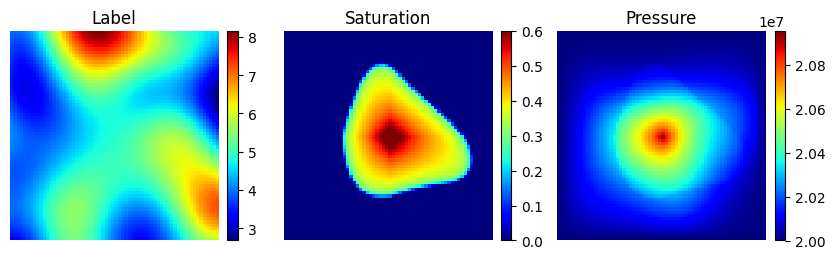

In [3]:
caseid = 300
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
im0 = ax[0].imshow(label[caseid, :, :], cmap='jet')
ax[0].set_title('Label')
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
im1 = ax[1].imshow(saturation[caseid, -1, :, :], cmap='jet', vmin=0, vmax=0.6)
ax[1].set_title('Saturation')
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
im2 = ax[2].imshow(pressure[caseid, -1, :, :], cmap='jet')
ax[2].set_title('Pressure')
fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')


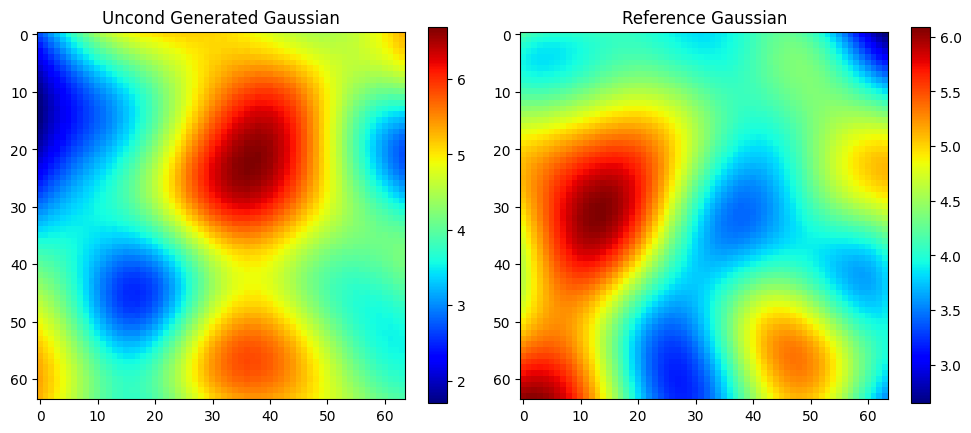

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
im0 = ax[0].imshow(gene[3, :, :], cmap='jet', interpolation='none')
ax[0].set_title('Uncond Generated Gaussian')
fig.colorbar(im0, ax=ax[0], shrink=0.8)

im1 = ax[1].imshow(label[4, :, :], cmap='jet')
ax[1].set_title('Reference Gaussian')
fig.colorbar(im1, ax=ax[1], shrink=0.8)
plt.tight_layout()


In [20]:
import gstools as gs
from gstools.random import MasterRNG
from tqdm import tqdm

k_gstools = []

def generate_random_fields(case_num):
    # generate random permeability fields
    gs_seed = MasterRNG(case_num * 123 + 321)
    color_style = 'jet'
    x = y = range(64)
    corr_len = 16
    x_len, y_len = corr_len, corr_len  # 10 too high

    model = gs.Gaussian(dim=2, var=1.0, len_scale=[x_len, y_len])

    srf = gs.SRF(model, mean=np.log(100), seed=gs_seed())

    field = srf.structured([x, y])
    data_array = srf.post_field(field=field, process=False)
    return data_array

for i in tqdm(range(10000)):
    k_gstools.append(generate_random_fields(i))
k_gstools = np.array(k_gstools)
print(k_gstools.shape)

100%|██████████| 10000/10000 [14:27<00:00, 11.53it/s]


(10000, 64, 64)


In [21]:
np.save('/ehome/zhao/DiffNO/dataset/K_gstools_1w.npy', k_gstools)